In [1]:
from utils import *
from param_search import *

In [6]:
EJ_subdivisions = 50
EC_subdivisions = 200
EL_subdivisions = 200

EJ_values = np.linspace(4, 16, EJ_subdivisions)
EC_values = np.linspace(0.1, 8, EC_subdivisions)
EL_values = np.linspace(0.01, 1, EL_subdivisions)
extents = []
total_jobs = 1000
existing_chunk_num = 0
num_points_per_chunk = total_jobs // len(EJ_values)
for EJ in EJ_values:
    extents.append([EC_values[0], EC_values[-1], EL_values[0], EL_values[-1]])

#     EC_grid, EL_grid = np.meshgrid(EC_values, EL_values)
#     EC_flat = EC_grid.flatten()
#     EL_flat = EL_grid.flatten()
#     EC_chunks = np.array_split(EC_flat, num_points_per_chunk)
#     EL_chunks = np.array_split(EL_flat, num_points_per_chunk)

#     for EC_chunk, EL_chunk in zip(EC_chunks, EL_chunks):
#         job = search_job(EJ, EC_chunk, EL_chunk)
#         with open(f'{existing_chunk_num}.pkl', 'wb') as f:
#             pickle.dump(job, f)
#         existing_chunk_num += 1


# def pack_pkl_files_to_zip(zip_filename="param_search.zip"):
#     # Create a new ZIP file
#     with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         # Loop through all files in the current directory
#         for filename in os.listdir('.'):
#             # Check if the file is a .pkl file with an integer name
#             name, ext = os.path.splitext(filename)
#             if ext == '.pkl' and name.isdigit():
#                 # Add the file to the ZIP
#                 zipf.write(filename)
#                 # Delete the .pkl file
#                 os.remove(filename)
                
# pack_pkl_files_to_zip()


In [7]:

one_two_grid = np.zeros((EJ_subdivisions, EC_subdivisions, EL_subdivisions))
zero_three_grid = np.zeros((EJ_subdivisions, EC_subdivisions, EL_subdivisions))
differential_stark_grid = np.zeros((EJ_subdivisions, EC_subdivisions, EL_subdivisions))
qubit_zero_lamb_grid = np.zeros((EJ_subdivisions, EC_subdivisions, EL_subdivisions))
detunning_grid = np.zeros((EJ_subdivisions, EC_subdivisions, EL_subdivisions))

# Initialize counter for existing chunks
existing_chunk_num = 0
# Loop through each EJ value
chunk_len = int(EC_subdivisions*EL_subdivisions / num_points_per_chunk)
for EJ_idx, EJ in enumerate(EJ_values):    
    # Initialize flattened arrays to store the results for this EJ value
    total_elements = EC_subdivisions * EL_subdivisions
    transition_flat = np.zeros(total_elements)
    zero_three_flat = np.zeros(total_elements)
    sum_of_differential_stark_on_qubit_12_flat = np.zeros(total_elements)
    sum_of_qubit_zero_lamb_on_osc_flat = np.zeros(total_elements)
    detunning_qubit01_flat = np.zeros(total_elements)
    
    flat_idx = 0
    # Read that many chunks for this EJ value
    for _ in range(total_jobs // len(EJ_values)):
        try:
            with gzip.GzipFile(f"param_search_result/result_{existing_chunk_num}.zip", "rb") as f:
                job = pickle.load(f)
            
            # Assuming job.results is a tuple of 4 numpy arrays, each of shape (len(job.EC_values), len(job.EL_values))
            transition, zero_three_transition,sum_of_differential_stark_on_qubit_12, sum_of_qubit_zero_lamb_on_osc, detunning_qubit01 = job.results
                        
            # Place the results back into the flattened arrays
            transition_flat[flat_idx:flat_idx + chunk_len] = transition
            zero_three_flat[flat_idx:flat_idx + chunk_len] = zero_three_transition
            sum_of_differential_stark_on_qubit_12_flat[flat_idx:flat_idx + chunk_len] = sum_of_differential_stark_on_qubit_12
            sum_of_qubit_zero_lamb_on_osc_flat[flat_idx:flat_idx + chunk_len] = sum_of_qubit_zero_lamb_on_osc
            detunning_qubit01_flat[flat_idx:flat_idx + chunk_len] = detunning_qubit01
            
            # Update the index for the flattened arrays
            flat_idx += chunk_len
        except Exception as e:
            print(f"Error occurred while loading chunk {existing_chunk_num}: {e}")
            transition_flat[flat_idx:flat_idx + chunk_len] = np.full(chunk_len, None)
            zero_three_flat[flat_idx:flat_idx + chunk_len] = np.full(chunk_len, None)
            sum_of_differential_stark_on_qubit_12_flat[flat_idx:flat_idx + chunk_len] = np.full(chunk_len, None)
            sum_of_qubit_zero_lamb_on_osc_flat[flat_idx:flat_idx + chunk_len] = np.full(chunk_len, None)
            detunning_qubit01_flat[flat_idx:flat_idx + chunk_len] = np.full(chunk_len, None)

            # Update the index for the flattened arrays
            flat_idx += chunk_len 
        existing_chunk_num += 1
    
    # Reshape the flattened arrays back into the original grid for this EJ value
    one_two_grid[EJ_idx, :, :] = transition_flat.reshape(EC_subdivisions, EL_subdivisions)
    zero_three_grid[EJ_idx, :, :] = zero_three_flat.reshape(EC_subdivisions, EL_subdivisions)
    differential_stark_grid[EJ_idx, :, :] = sum_of_differential_stark_on_qubit_12_flat.reshape(EC_subdivisions, EL_subdivisions)
    qubit_zero_lamb_grid[EJ_idx, :, :] = sum_of_qubit_zero_lamb_on_osc_flat.reshape(EC_subdivisions, EL_subdivisions)
    detunning_grid[EJ_idx, :, :] = detunning_qubit01_flat.reshape(EC_subdivisions, EL_subdivisions)


Error occurred while loading chunk 41: Ran out of input
Error occurred while loading chunk 81: Ran out of input
Error occurred while loading chunk 82: Ran out of input
Error occurred while loading chunk 101: Ran out of input
Error occurred while loading chunk 881: Ran out of input
Error occurred while loading chunk 882: Ran out of input


In [11]:
from matplotlib.colors import LogNorm
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

# Assuming EJ_values, one_two, detunning, qubit_zero_lamb, differential_stark, extents are already defined

def plot_all(EJ):
    idx = np.argmin(np.abs(EJ_values - EJ))
    
    plt.figure(figsize=(13, 8))
    
    cmap_choice = 'inferno'  # Choose your colormap here
    
    plt.subplot(2, 3, 1)
    plt.imshow(one_two_grid[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm(vmin=1e-5), cmap=cmap_choice)
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'one-two transition for EJ = {EJ}')
    
    plt.subplot(2, 3, 2)
    plt.imshow(detunning_grid[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm(vmin=1e-5), cmap=cmap_choice)
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'detunning')
    
    plt.subplot(2, 3, 3)
    plt.imshow(qubit_zero_lamb_grid[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm(vmin=1e-5), cmap=cmap_choice)
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'qubit_zero_lamb')
    
    plt.subplot(2, 3, 4)
    plt.imshow(differential_stark_grid[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm(vmin=1e-5), cmap=cmap_choice)
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'differential_stark_on_qubit_12')

    plt.subplot(2, 3, 5)
    plt.imshow(zero_three_grid[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm(), cmap=cmap_choice)
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'zero_three transition')
    
    plt.tight_layout()
    plt.show()

interact(plot_all, EJ=FloatSlider(min=EJ_values[0], max=EJ_values[-1], step=(EJ_values[1]-EJ_values[0]), value=EJ_values[0]))


interactive(children=(FloatSlider(value=4.0, description='EJ', max=16.0, min=4.0, step=0.24489795918367374), O…

<function __main__.plot_all(EJ)>

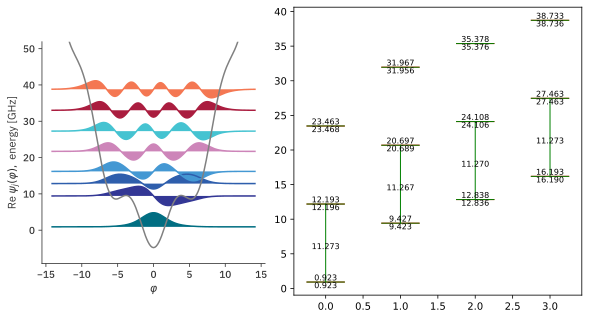

In [17]:
g_strength = 0.3
EJ = 4.8
EC = 4
EL = 0.8



qubit_level = 5
osc_level = 6
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
q_evals = qbt.eigenvals()
E_osc = q_evals[3] - q_evals[0]-4

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())

plot_specturum(qbt, osc, hilbertspace)

In [2]:
scqubits.GUI()

Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

In [56]:


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


tot_time = 800
tlist = np.linspace(0, tot_time, tot_time*2)

A_square = 0.002

def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.0
decay_term = kappa*a


results = []
for i in range(4):
    temp = solve_with_mesolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        # c_ops= [ decay_term],
        options=qutip.Options(store_states=True,nsteps=20000,num_cpus = 7),
        
    )
    results.append(temp)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

10.0%. Run time:   0.93s. Est. time left: 00:00:00:08
20.0%. Run time:   1.90s. Est. time left: 00:00:00:07
30.0%. Run time:   2.90s. Est. time left: 00:00:00:06
40.0%. Run time:   3.88s. Est. time left: 00:00:00:05
50.0%. Run time:   4.86s. Est. time left: 00:00:00:04
60.0%. Run time:   5.84s. Est. time left: 00:00:00:03
70.0%. Run time:   6.79s. Est. time left: 00:00:00:02


Traceback (most recent call last):
  File "qutip/cy/cqobjevo.pyx", line 212, in qutip.cy.cqobjevo.CQobjEvo.mul_vec
capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
  File "qutip/cy/cqobjevo.pyx", line 679, in qutip.cy.cqobjevo.CQobjEvoTd._mul_vec
  File "qutip/cy/cqobjevo.pyx", line 293, in qutip.cy.cqobjevo.CQobjEvo._factor_dyn
  File "qutip/cy/cqobjevo.pyx", line 278, in qutip.cy.cqobjevo.CQobjEvo._factor
  File "/Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qutip/qobjevo.py", line 1820, in __call__
    def __call__(self, t, args={}):
KeyboardInterrupt


: 

: 

In [55]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1599), Output…